The Bigram model is bad, it only takes one character context, the next character posisibility is out of 27, if we had 2 char context, we would hav had 27*27, 3 then 27*27*27, and so it gets worse.
Bigram (one character predicts the next one with a lookup table of counts) is done

And so now we will be moving on to **MLP, following Bengio et al. 2003**
Multi layer Perceptrons or the Neural Networks to predict the next word in the sequence.

This paper has vocablary of 17,000 words(word based language model), but we are still goonna stick with character based language model approach. In the paper, each word has 30 features, that means the word is embedded ina  30 dimensional vector space. Initially assigned randomly but then trained and fine tuned the weights. Lateron words with similar meanings will be having close vectors, like sofa and chair. They use the same core technique : **"maximize the log-likelihood of the training data"**




In [ ]:
import torch
from torch.nn import functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
#read in all the words
words = open('names.txt', 'r').read().splitlines()
print(words[:8])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [ ]:
len(words)

32033

In [ ]:
#build the vocablary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
C = torch.randn((27, 2))

In [ ]:
C[5]

tensor([0.2830, 1.8224])

In [ ]:
C[torch.tensor([5,6,7])]

tensor([[ 0.2830,  1.8224],
        [-0.0192,  0.1240],
        [-0.0197, -0.6221]])

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([1.3203, 0.8398])

In [ ]:
C[X].shape

torch.Size([32, 3, 2])

In [ ]:
X[13,2]

tensor(1)

In [ ]:
C[X][13,2]

tensor([-0.4270, -1.3921])

In [ ]:
C[1]

tensor([-0.4270, -1.3921])

In [ ]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In short Pytorch embedding is awesome to embed everything simultaneosly

In [ ]:
W1 = torch.randn((6, 100))   # 3*2 = 6
b1 = torch.randn(100)

In [ ]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (684438x2 and 6x100)

torch.cat - concatenates the given sequence of seq tensors in the given dimension. All tensors must either have the same shape(except in the concatenating dimension) or be empty.

In [ ]:
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape

torch.Size([32, 6])

Right now we only have 3 inputs i.e block size = 3, and so later it would not generalize, like what if we had 5


torch.unbind - removes a tensor dimension.  Returns a tuple of all slices along a given dimension, already without it.

In [ ]:
torch.cat(torch.unbind(emb,1), 1).shape

torch.Size([32, 6])

In [ ]:
 emb.shape

torch.Size([32, 3, 2])

In [ ]:
emb.view(32,6) == torch.cat(torch.unbind(emb,1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

There is a torch library where instead of concatenating and changing dimensions, we can just use emb.view to do the same

In [ ]:
emb.view(32,6) @ W1 + b1

tensor([[-2.7899,  0.1686, -0.6752,  ..., -0.3054,  2.5374,  1.4913],
        [-3.0914,  0.4720,  0.7075,  ..., -1.9201,  4.3429,  2.3366],
        [-5.8973, -3.0655,  0.0681,  ..., -1.3055,  2.1241,  2.1134],
        ...,
        [-2.8016,  1.9937, -1.2880,  ...,  1.2231,  1.7000,  0.2216],
        [-2.8323, -1.6103, -2.6349,  ...,  0.7972,  1.9066, -0.3981],
        [ 2.0042,  3.4538, -1.5144,  ...,  3.4479, -0.7690, -1.3940]])

Look, the multiplications works, which we were all after

In [ ]:
h = emb.view(32,6) @ W1 + b1

In [ ]:
h.shape

torch.Size([32, 100])

100 dimensional activations for every one of our 32 examples

In [ ]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

-1 defines whatever the dimensions are needed like pytorch infers that it will automatically arrive at 32 or whatever it is if m is of different size, (we moved from hard coding it to  )

In [ ]:
h

tensor([[-2.7899,  0.1686, -0.6752,  ..., -0.3054,  2.5374,  1.4913],
        [-3.0914,  0.4720,  0.7075,  ..., -1.9201,  4.3429,  2.3366],
        [-5.8973, -3.0655,  0.0681,  ..., -1.3055,  2.1241,  2.1134],
        ...,
        [-2.8016,  1.9937, -1.2880,  ...,  1.2231,  1.7000,  0.2216],
        [-2.8323, -1.6103, -2.6349,  ...,  0.7972,  1.9066, -0.3981],
        [ 2.0042,  3.4538, -1.5144,  ...,  3.4479, -0.7690, -1.3940]])

In [ ]:
h.shape # hidden layer of acticvations for every one of our 100 activations

torch.Size([32, 100])

Now lets create the final layer

In [ ]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [ ]:
#logits are the output of the final layer

logits = h @ W2 + b2

In [ ]:
logits.shape

torch.Size([32, 27])

Now exactly what we did previosly in Makemore1, we will exponentiate the logits to get our fake counts and then normalize them to get our probablities

In [ ]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([32, 27])

Now just like the previous video we would like to index into the rows of prob and in each row we would like to pluck out the probablities assigned to the correct character as given below

In [ ]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(inf)

In [ ]:
# ------------ now made respectable :) ---------------

In [ ]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [ ]:
# forward pass as we developed it

emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

17.7697 says how well the neural netork works with the curent set of parameters

Torch.NN.Functional.Cross_Entropy  - > computes the entropy loss between input and the target. Using this also makes bakward pass calculation easier, as all the calculations happen under one kernel, and the things can be much more well behaved

In [ ]:
F.cross_entropy(logits, Y)

ValueError: Expected input batch_size (32) to match target batch_size (228146).

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []

# Forward and Backward pass
for i in range(1000):

  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))


  #forward pass
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y[ix]) # loss
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  #track stats
  lri.append(lre[i])
  lossi.append(loss.item())


print(loss.item())

10.337976455688477


taking to much time, so we make use of mini batches, but it makes the directions unreliable

approx direction and then take steps >>> calculate the exact direction and then take the steps

In [ ]:
  emb = C[X] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y) # loss
  loss

tensor(7.4695, grad_fn=<NllLossBackward0>)

we don't know if we are going to slow or too fast, like how did we decide -0.1?
reduce the iterations -> make -0.1 t0 -0.0001 -> study the print(loss.item) "the one below the forward pass" -> make -0.0001 to -1 to make gradient explode and then estimate the range


or the best step, see the lr implementation

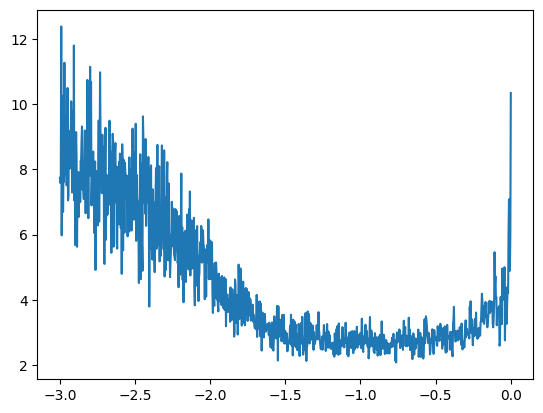

In [ ]:
plt.plot(lri, lossi)

as we can see -1 i.e -0.1 was a very good lr, which we are gonna keep

In [ ]:
lri = []
lossi = []

# Forward and Backward pass
for i in range(10000):

  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))


  #forward pass
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y[ix]) # loss
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  #track stats
  #lri.append(lre[i])
  #lossi.append(loss.item())


print(loss.item())

2.415680170059204


In [ ]:
  emb = C[X] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y) # loss
  loss

tensor(2.3715, grad_fn=<NllLossBackward0>)

at the last of the trainig stages make 0.1 to 0.01, just to slow down at the end as we near the min loss

In the bigram model we had loss of 2.45 and now we have 2.37, which is already a win

But there is a problem, since dataset is small, it is memorising it, which leads to overfitting, we get to know that when we try to sample datasets from it, we only get  the same examples which were provided to you

To deal with this we split our dataset into training set, dev/validation set (used over the hyperparameters of the model) and test set

In [ ]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random # randomly shuffling up the words
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [ ]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []

# Forward and Backward pass
for i in range(30000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))


  #forward pass
  emb = C[Xtr[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr[ix]) # loss
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  #track stats
  #lri.append(lre[i])
  #lossi.append(loss.item())


print(loss.item())

2.3036882877349854


In [ ]:
  emb = C[Xtr] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr) # loss
  loss

tensor(2.4003, grad_fn=<NllLossBackward0>)

In [ ]:
  emb = C[Xdev] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ydev) # loss
  loss

tensor(2.4034, grad_fn=<NllLossBackward0>)

Training loss and the dev loss comes to be similar, case of underfitting, which indicates our network is very tiny, very small, so lets fix that

In [ ]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random # randomly shuffling up the words
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [ ]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)   # 100 is pumped to 300
b1 = torch.randn(300, generator=g)        # which in turn we need 300 biases
W2 = torch.randn((300, 27), generator=g)  # and then we need 300 inputs into the final layer
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) # number of parameters in total

10281

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []
stepi = []

# Forward and Backward pass
for i in range(30000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))


  #forward pass
  emb = C[Xtr[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr[ix]) # loss
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  lr = 0.05
  for p in parameters:
    p.data += -lr * p.grad

  #track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.item())


print(loss.item())

2.198383331298828


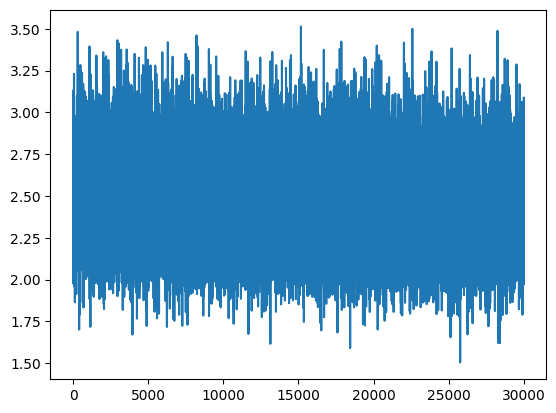

In [ ]:
plt.plot(stepi, lossi)

The thickness in the bottom signifies the work done on mini batches

In [ ]:
  emb = C[Xtr] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr) # loss
  loss

tensor(2.2935, grad_fn=<NllLossBackward0>)

In [ ]:
  emb = C[Xdev] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ydev) # loss
  loss

tensor(2.3080, grad_fn=<NllLossBackward0>)

It is not improving significantly cause: the mini batch is too small and also the embeddings have too many characters in 2 dimensions and the neural net is not able to utilize the space very effectively, which is the bottleneck to our performance

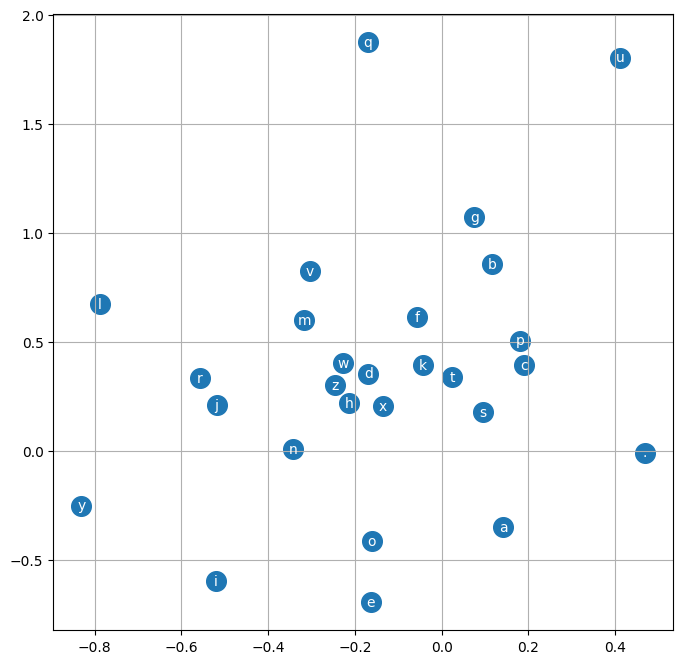

In [ ]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

Now lets try to increase the embeddings and do the process again

In [ ]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random # randomly shuffling up the words
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [ ]:
Xtr.shape, Ytr.shape # dataset

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)     # 2 embeddings pumped to 10
W1 = torch.randn(( 30, 200), generator=g)   # 100 is pumped to 300 now down to 200 , 3 * 10 = 30
b1 = torch.randn(200, generator=g)        # which in turn we need 300 biases
W2 = torch.randn((200, 27), generator=g)  # and then we need 300 inputs into the final layer
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []
stepi = []


In [ ]:
# Forward and Backward pass
for i in range(50000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))


  #forward pass
  emb = C[Xtr[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)   6 -> 30
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr[ix]) # loss
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  lr = 0.01
  for p in parameters:
    p.data += -lr * p.grad

  #track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())


print(loss.item())

2.0004515647888184


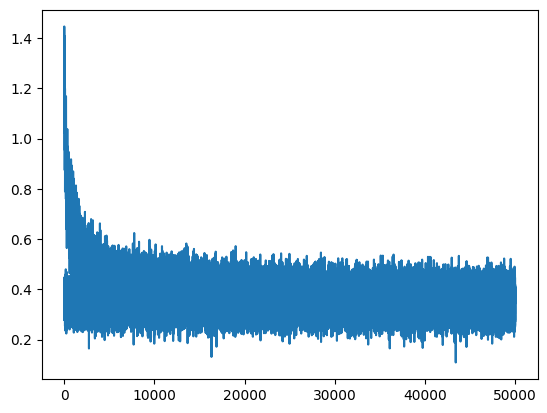

In [ ]:
#lets plot the log loss instead of normal loss, as log squashes everything in the graph
plt.plot(stepi, lossi)

In [ ]:
  emb = C[Xtr] # (32,3,2)
  h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)   6 - > 30
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr) # loss
  loss

tensor(2.2201, grad_fn=<NllLossBackward0>)

In [ ]:
  emb = C[Xdev] # (32,3,2)
  h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)   6 - > 30
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ydev) # loss
  loss

tensor(2.2432, grad_fn=<NllLossBackward0>)

we beat the 2.35 mark by having 2.20 and also the train loss and val loss are starting to depart, which means overfitting just started